# Literature

<img src="https://www.researchgate.net/publication/366287867/figure/fig1/AS:11431281107486430@1671074718081/The-TSVF-regime-Bandstructures-of-a-zigzag-and-b-bearded-graphene-with.ppm" alt="A Cat" width="800">

# Model

In [10]:
from topological_insulator import Problem

data_path = "../../topological_insulator/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [ ]:
import numpy as np

subs = ["A", "B"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    for nn_label in subs:
        if sub_label == nn_label:
            continue
        parser["nn_hopping"][nn_label]["t_ss_sigma"] = -np.sqrt(2)

In [12]:
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ = "reduced",
    dangling_bonds = False
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


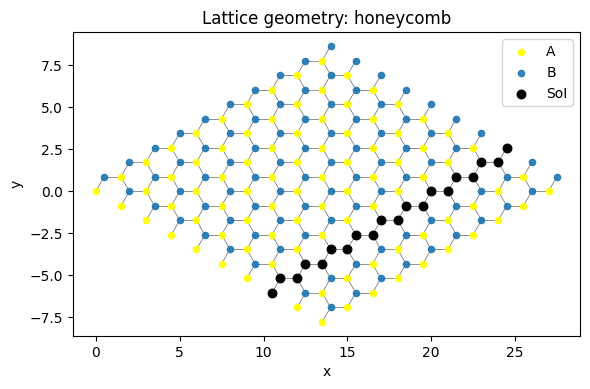

In [13]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
)

In [14]:
problem.geometry.T

array([ 1.5      , -0.8660254])

## Bearded Zig-Zag Edge

In [15]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


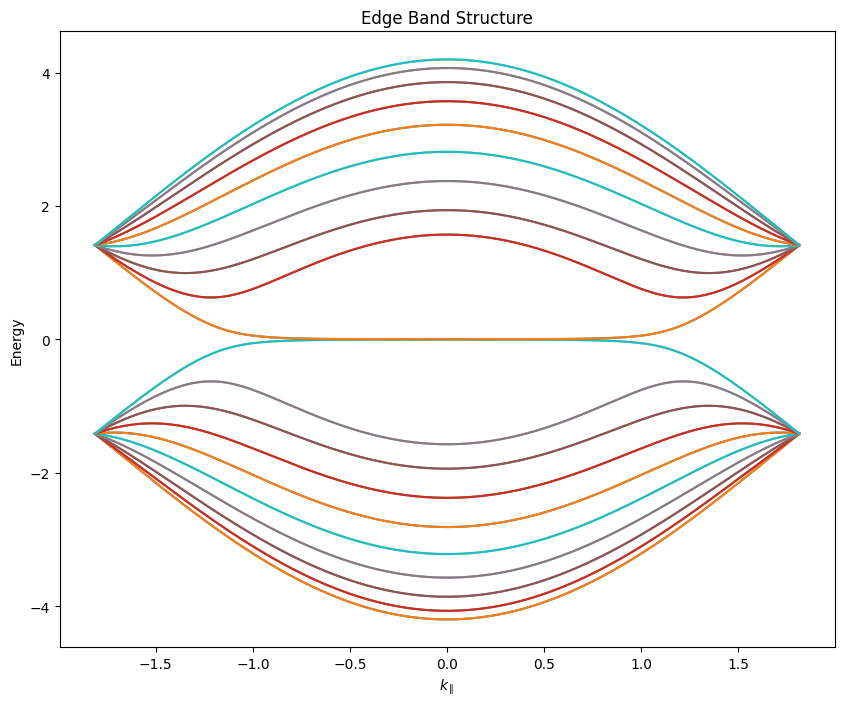

In [16]:
problem.plot(plot_type="dispersion", location=location)